# Mutation rates over time

Plot the average number of mutations per edge, normalised by edge area, and bin this by edge (i.e. mutation) time, by taking the midpoint time of each edge.

If we use the `find_problematic` ARG, this has very little site filtering, so hopefully will show the full mutational spectrum.

In [20]:
# Get the Viridian ARG
import collections
import os
import tskit
import tszip
import sc2ts
import numpy as np

ts_dir = "../data"
filename = "find_problematic_v2-2022-09-01.ts.il.tsz"
ts = tszip.decompress(os.path.join(ts_dir, filename))
print(
    f"Loaded {ts.nbytes/1e6:0.1f} megabyte SARS-CoV2 genealogy of {ts.num_samples} strains",
    f"({ts.num_trees} trees, {ts.num_mutations} mutations over {ts.sequence_length} basepairs).",
    f"Last collection date is {ts.node(ts.samples()[-1]).metadata['date']}",
)
ti = sc2ts.TreeInfo(ts)
dates = {"2021-11-08": "Omicron", "2020-10-05": "Delta"}
date_days = {voc: [] for voc in dates.values()}
for u in ts.samples():
    nd = ts.node(u)
    if nd.metadata.get("date") in dates:
        date_days[dates[nd.metadata.get("date")]].append(nd.time)
date_days = {k: np.mean(v) for k, v in date_days.items()}

Loaded 468.9 megabyte SARS-CoV2 genealogy of 462049 strains (174 trees, 868199 mutations over 29904.0 basepairs). Last collection date is 2022-09-01


Counting descendants :   0%|          | 0/545076 [00:00<?, ?it/s]

Indexing metadata    :   0%|          | 0/545076 [00:00<?, ?it/s]

Classifying mutations:   0%|          | 0/868199 [00:00<?, ?it/s]

In [2]:
av_mu = ts.num_mutations / ((ts.edges_right - ts.edges_left) * (ts.nodes_time[ts.edges_parent] - ts.nodes_time[ts.edges_child])).sum()

In [3]:
# NB: currently you will need to install a version of tsdate that can deal with historical samples
# e.g. via
# !pip install git+https://github.com/tskit-dev/tsdate@refs/pull/433/head

import tsdate
# NB could also set match_segregating_sites=True, but that seems not to make a difference
# if rescaling_intervals=0
dts = tsdate.date(ts, mutation_rate=av_mu, rescaling_intervals=0, constr_iterations=100, time_units=ts.time_units, allow_unary=True)

Looking at 545124 edges, with 868199 mutations


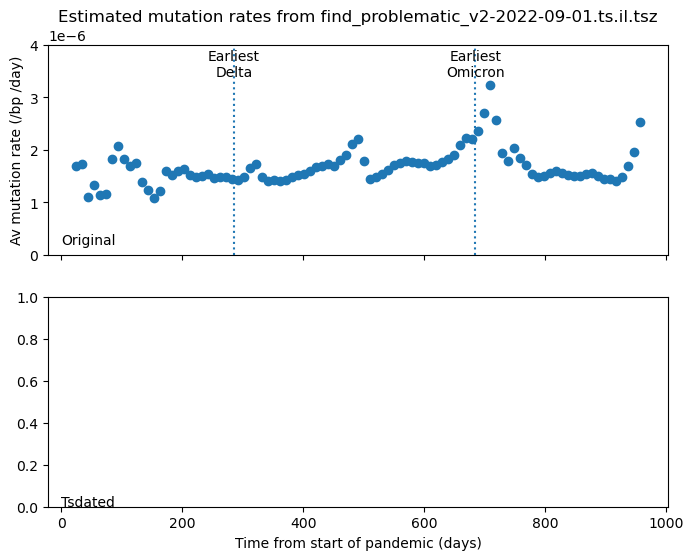

In [21]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, sharex=True, figsize=(8, 6))
axes[0].set_title(f"Estimated mutation rates from {filename}")
axes[-1].set_xlabel(f"Time from start of pandemic ({ts.time_units})")

timeslices = np.linspace(0, np.nextafter(ts.max_time, np.inf), 100)
# cut off 2 from top and bottom, as these may suffer from truncation bias
timeslices = timeslices[2:-2]

for ax, sts in zip(axes, [ts.simplify()], dts.simplify()]):
    print("Looking at", sts.num_edges, "edges, with", sts.num_mutations, "mutations")
    nodes_time =sts.nodes_time
    parent_time = nodes_time[sts.edges_parent]
    child_time = nodes_time[sts.edges_child]
    edge_area = (parent_time - child_time) * (sts.edges_right - sts.edges_left)
    
    edge_time = (parent_time + child_time) / 2
    mutation_edges = np.array([m.edge for m in sts.mutations()])
    num_muts_per_edge = np.bincount(mutation_edges, minlength=sts.num_edges)
    
    
    x = []
    y = []
    
    for lo, hi in zip(timeslices[:-1], timeslices[1:]):
        x.append((lo + hi) / 2)
        focal_edges = np.logical_and(edge_time >= lo, edge_time < hi)
        mut_rate = np.sum(num_muts_per_edge[focal_edges]) / np.sum(edge_area[focal_edges])
        y.append(mut_rate)
        
    ax.scatter(ts.max_time - np.array(x), y)
    
    for voc, t in date_days.items():
        ax.axvline(ts.max_time - t, ls=":")
        ax.text(ts.max_time - t, 3.4e-6, f"Earliest\n{voc}", ha="center")
    
    ax.set_ylabel("Av mutation rate (/bp /day)");
    ax.set_ylim(0, 4e-6)

axes[0].text(0, 2e-7, "Original")
axes[1].text(0, 2e-7, "Tsdated");

The increase in mutation rate at the present day may be an artefact, but the peak associated with the omicron wave is probably real. The gradual increase at 400 days and 600 days seems worth thinking about too, as well as the peak/drop at 500 days.

In [ ]:
Break down into Scorpio categories

In [31]:
Scorpio_map = collections.defaultdict(set)
for u in ts.samples():
    nd = ts.node(u)
    scorpio = nd.metadata.get("Viridian_scorpio")
    if scorpio:
        Scorpio_map[scorpio].add(nd.metadata["Viridian_pangolin"])
Scorpio_index = {s: i for i, s in enumerate(Scorpio_map.keys())}
Scorpio_index["unknown"] = len(Scorpio_index)

In [33]:
# Check no overlap between pangos for each scorpio
#assert sum([len(v) for v in Scorpio_map.values()]) == len({pango for v in Scorpio_map.values() for pango in v})
Pango_map = {
    pango: Scorpio_index[scorpio]
    for scorpio, v in Scorpio_map.items()
    for pango in v
}


Looking at 545124 edges, with 868199 mutations
Beta (B.1.351-like) 509
Alpha (B.1.1.7-like) 140
Epsilon (B.1.427-like) 575
Epsilon (B.1.429-like) 1341
B.1.1.7-like+E484K 39807
A.23.1-like 0
A.23.1-like+E484K 38
Eta (B.1.525-like) 157
Iota (B.1.526-like) 6459
B.1.1.318-like 249
Gamma (P.1-like) 992
B.1.617.1-like 72
Delta (B.1.617.2-like) 9351
Delta (AY.4-like) 10163


/var/folders/tj/03zrlgjj54qfndzhwrgp3tqc0000gn/T/ipykernel_95624/338669374.py:32: RuntimeWarning: invalid value encountered in scalar divide
  mut_rate = np.sum(num_muts_per_edge[focal_edges]) / np.sum(edge_area[focal_edges])


Delta (B.1.617.2-like) +K417N 20092
Mu (B.1.621-like) 132
AV.1-like 7
Delta (AY.4.2-like) 40835
Omicron (BA.1-like) 13632
timeslice: (np.float64(19.81818181818182), np.float64(29.72727272727273)),  9
Probable Omicron (BA.1-like) 43
Probable Omicron (Unassigned) 0
Omicron (BA.2-like) 69203
Omicron (Unassigned) 12047
Omicron (XE-like) 103
Omicron (BA.4-like) 2659
Omicron (BA.5-like) 273959
unknown 42559


Text(0, 2e-07, 'Original')

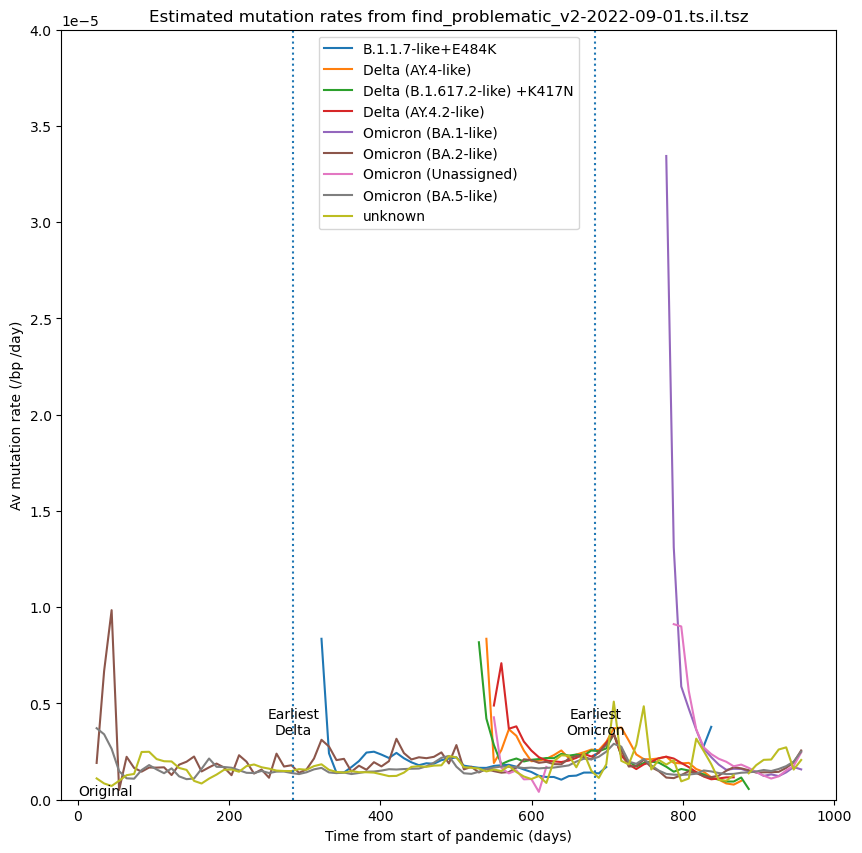

In [55]:
fig, axes = plt.subplots(1, sharex=True, figsize=(10, 10))
axes = [axes]
axes[0].set_title(f"Estimated mutation rates from {filename}")
axes[-1].set_xlabel(f"Time from start of pandemic ({ts.time_units})")

for ax, sts in zip(axes, [ts.simplify()]): #, dts.simplify()]):
    print("Looking at", sts.num_edges, "edges, with", sts.num_mutations, "mutations")
    nodes_time =sts.nodes_time
    parent_time = nodes_time[sts.edges_parent]
    child_time = nodes_time[sts.edges_child]
    edge_area = (parent_time - child_time) * (sts.edges_right - sts.edges_left)
    
    edge_time = (parent_time + child_time) / 2
    mutation_edges = np.array([m.edge for m in sts.mutations()])
    num_muts_per_edge = np.bincount(mutation_edges, minlength=sts.num_edges)

    data = {}
    node_scorpio_index = np.array([
        Pango_map.get(ts.node(u).metadata.get("Imputed_Viridian_pangolin"), Scorpio_index["unknown"])
        for u in sts.edges_parent
    ])
    for scorpio, idx in Scorpio_index.items():
        scorpio_edges = node_scorpio_index == idx
        print(scorpio, np.sum(scorpio_edges))
        if np.sum(scorpio_edges) > 1e4:
            data[scorpio] = {"x": [], "y": []}
            for lo, hi in zip(timeslices[:-1], timeslices[1:]):
                focal_edges = np.logical_and(scorpio_edges, np.logical_and(edge_time >= lo, edge_time < hi))
                if lo == timeslices[0] and scorpio == "Omicron (BA.1-like)":
                    print(f"timeslice: {lo, hi}, ", sum(focal_edges))
                data[scorpio]["x"].append((lo + hi) / 2)
                mut_rate = np.sum(num_muts_per_edge[focal_edges]) / np.sum(edge_area[focal_edges])
                data[scorpio]["y"].append(mut_rate)

    for scorpio, d in data.items():
        ax.plot(ts.max_time - np.array(d['x']), d['y'], label=scorpio)
    
    for voc, t in date_days.items():
        ax.axvline(ts.max_time - t, ls=":")
        ax.text(ts.max_time - t, 3.4e-6, f"Earliest\n{voc}", ha="center")
    
    ax.set_ylabel("Av mutation rate (/bp /day)");
    ax.set_ylim(0, 4e-5)
    ax.legend()

axes[0].text(0, 2e-7, "Original")


(array([8.0900e+02, 6.4060e+03, 1.0262e+04, 7.2710e+03, 3.1940e+03,
        7.5400e+02, 1.9300e+02, 3.7000e+01, 2.0000e+00, 2.5000e+01]),
 array([702. , 721.9, 741.8, 761.7, 781.6, 801.5, 821.4, 841.3, 861.2,
        881.1, 901. ]),
 <BarContainer object of 10 artists>)

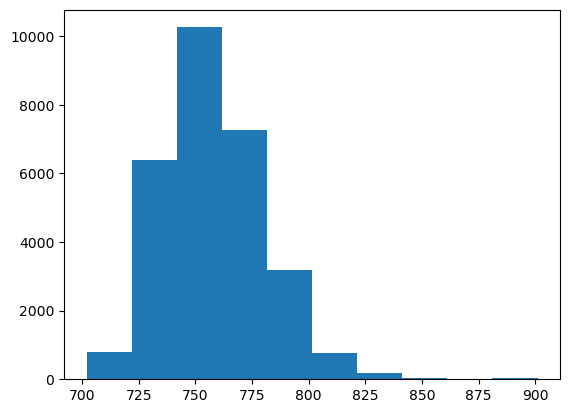

In [53]:
plt.hist([
    ts.max_time - nd.time
    for nd in ts.nodes()
    if Pango_map.get(nd.metadata.get("Imputed_Viridian_pangolin"), Scorpio_index["unknown"]) == Scorpio_index["Omicron (BA.1-like)"]
])

In [27]:
for nd in ts.nodes()
    if Pango_map.get(nd.metadata.get("Imputed_Viridian_pangolin"), Scorpio_index["unknown"]) == Scorpio_index["Omicron (BA.1-like)"]:
        if nd.time 


{}

In [28]:
Scorpio_map

defaultdict(set, {})